In [32]:
import sys
import os
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, roc_curve)
from sklearn.calibration import CalibratedClassifierCV

from utils.data_loader import load_images
from utils.features import extract_combined_advanced
from utils.calibration import (compute_ece, plot_reliability_diagram,
                                plot_reliability_comparison)
from utils.ood import (fit_mahalanobis, mahalanobis_scores,
                       set_ood_threshold, flag_ood)

sns.set_style('whitegrid')

DATA_ROOT                = '../data/chest_xray'
OUTPUT_PLOTS             = '../outputs/plots'
OUTPUT_MODELS            = '../outputs/models'
IMG_SIZE                 = (128, 128)
RANDOM_STATE             = 42
MAX_TRAIN_ADVANCED       = None
N_PCA_COMPONENTS         = 50
OOD_THRESHOLD_PERCENTILE = 95
NOISE_STD                = 2.0

os.makedirs(OUTPUT_PLOTS,  exist_ok=True)
os.makedirs(OUTPUT_MODELS, exist_ok=True)

print("Setup complete.")
print(f"Training cap   : {MAX_TRAIN_ADVANCED} (None = full dataset)")
print(f"PCA components : {N_PCA_COMPONENTS}")
print(f"OOD percentile : {OOD_THRESHOLD_PERCENTILE}")


Setup complete.
Training cap   : None (None = full dataset)
PCA components : 50
OOD percentile : 95



## Notebook 02 — Advanced ML

Three improvements over Notebook 01:

1. Richer features — GLCM, intensity histogram, region statistics
   added to HOG + LBP. Every feature traces to a specific EDA finding.

2. Full training dataset — Notebook 01 capped at 500 per class.
   Notebook 02 uses all ~5216 training images because:
   - Random Forest handles class imbalance via class_weight='balanced'
   - Tree ensembles scale well — more data reduces variance
   - Discarding real pneumonia cases is clinically unjustifiable

3. OOD detection — Mahalanobis distance flags inputs outside the
   training distribution before classification reaches the model.

In [34]:
print("Loading FULL training set (no per-class cap)...")
print("-" * 50)
X_train_raw, y_train = load_images(
    split='train',
    data_root=DATA_ROOT,
    img_size=IMG_SIZE,
    max_per_class=MAX_TRAIN_ADVANCED
)

print()
print("Loading test set...")
print("-" * 50)
X_test_raw, y_test = load_images(
    split='test',
    data_root=DATA_ROOT,
    img_size=IMG_SIZE,
    max_per_class=None
)

print()
print("=" * 50)
print("Shapes")
print("=" * 50)
print(f"X_train_raw : {X_train_raw.shape}")
print(f"y_train     : {y_train.shape}")
print(f"X_test_raw  : {X_test_raw.shape}")
print(f"y_test      : {y_test.shape}")

print()
print("=" * 50)
print("Class distribution")
print("=" * 50)
n_normal    = (y_train == 0).sum()
n_pneumonia = (y_train == 1).sum()
ratio       = n_pneumonia / n_normal

print(f"Train — NORMAL: {n_normal},  PNEUMONIA: {n_pneumonia}")
print(f"Imbalance ratio: {ratio:.2f}:1  (PNEUMONIA:NORMAL)")
print(f"Test  — NORMAL: {(y_test==0).sum()},  "
      f"PNEUMONIA: {(y_test==1).sum()}")
print()
print("class_weight='balanced' in Random Forest will automatically")
print(f"upweight NORMAL class by {ratio:.1f}x during training.")


Loading FULL training set (no per-class cap)...
--------------------------------------------------
  Loaded 1341 images from NORMAL
  Loaded 3875 images from PNEUMONIA
  Total: 5216 images — shape (5216, 128, 128)

Loading test set...
--------------------------------------------------
  Loaded 234 images from NORMAL
  Loaded 390 images from PNEUMONIA
  Total: 624 images — shape (624, 128, 128)

Shapes
X_train_raw : (5216, 128, 128)
y_train     : (5216,)
X_test_raw  : (624, 128, 128)
y_test      : (624,)

Class distribution
Train — NORMAL: 1341,  PNEUMONIA: 3875
Imbalance ratio: 2.89:1  (PNEUMONIA:NORMAL)
Test  — NORMAL: 234,  PNEUMONIA: 390

class_weight='balanced' in Random Forest will automatically
upweight NORMAL class by 2.9x during training.



## Advanced Feature Extraction

Five feature types — each motivated by a specific EDA finding:

| Feature        | EDA Finding | What it captures                      |
|----------------|-------------|---------------------------------------|
| HOG            | Finding 2   | Edge directions, structural gradients |
| LBP            | Finding 2   | Local texture micropatterns           |
| GLCM           | Finding 2   | Block-level texture statistics        |
| Intensity hist | Finding 3   | Global brightness distribution shape  |
| Region stats   | Finding 4   | Spatial localization of brightness    |

GLCM on ~5216 images takes 15-25 minutes.
Features are saved to disk after first run.
Subsequent runs load from disk instantly.

In [36]:
TRAIN_FEAT_PATH = f'{OUTPUT_MODELS}/X_train_adv.npy'
TEST_FEAT_PATH  = f'{OUTPUT_MODELS}/X_test_adv.npy'
Y_TRAIN_PATH    = f'{OUTPUT_MODELS}/y_train_full.npy'
Y_TEST_PATH     = f'{OUTPUT_MODELS}/y_test.npy'

if os.path.exists(TRAIN_FEAT_PATH):
    print("Saved features found. Loading from disk...")
    print("(delete .npy files in outputs/models/ to re-extract)")
    print("-" * 50)
    X_train_adv = np.load(TRAIN_FEAT_PATH)
    X_test_adv  = np.load(TEST_FEAT_PATH)
    y_train     = np.load(Y_TRAIN_PATH)
    y_test      = np.load(Y_TEST_PATH)
    print(f"X_train_adv : {X_train_adv.shape}")
    print(f"X_test_adv  : {X_test_adv.shape}")

else:
    print("No saved features found. Extracting now...")
    print("GLCM on full dataset takes 15-25 minutes.")
    print("=" * 50)

    print("\nExtracting training features...")
    X_train_adv = extract_combined_advanced(X_train_raw)

    print("\nExtracting test features...")
    X_test_adv = extract_combined_advanced(X_test_raw)

    print("\nSaving to disk...")
    np.save(TRAIN_FEAT_PATH, X_train_adv)
    np.save(TEST_FEAT_PATH,  X_test_adv)
    np.save(Y_TRAIN_PATH,    y_train)
    np.save(Y_TEST_PATH,     y_test)
    print("Saved. Future runs will load instantly.")

print()
print("=" * 50)
print("Feature matrix shapes")
print("=" * 50)
print(f"X_train_adv : {X_train_adv.shape}")
print(f"X_test_adv  : {X_test_adv.shape}")
print(f"y_train     : {y_train.shape}")
print(f"y_test      : {y_test.shape}")


Saved features found. Loading from disk...
(delete .npy files in outputs/models/ to re-extract)
--------------------------------------------------
X_train_adv : (5216, 1843)
X_test_adv  : (624, 1843)

Feature matrix shapes
X_train_adv : (5216, 1843)
X_test_adv  : (624, 1843)
y_train     : (5216,)
y_test      : (624,)



## PCA — Dimensionality Reduction

Advanced feature vector is ~1213 dimensions.

Two reasons PCA is required before OOD detection:

1. Covariance matrix in 1213 dimensions is 1213×1213.
   Even with 5216 training samples this can be ill-conditioned.
   50 dimensions gives a stable, invertible covariance matrix.

2. Features are correlated — GLCM homogeneity and LBP uniform
   patterns both capture texture smoothness. PCA removes this
   redundancy so each dimension carries independent information.

Critical discipline: PCA fitted ONLY on training data.
Test data is transformed using the fitted PCA — never refitted.
This prevents data leakage.

Fitting StandardScaler on training data...
Scaled — train: (5216, 1843), test: (624, 1843)

Fitting PCA (50 components) on training data...
Variance retained : 57.70%
X_train_pca       : (5216, 50)
X_test_pca        : (624, 50)


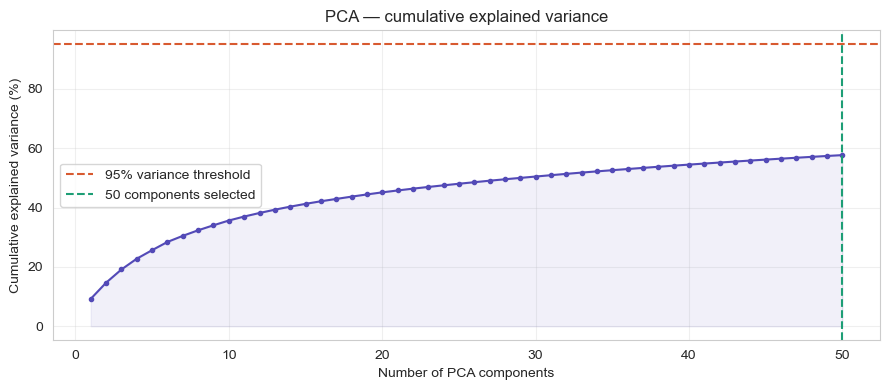

Saved → outputs/plots/pca_explained_variance.png
Scaler and PCA saved.


In [37]:
print("Fitting StandardScaler on training data...")
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_adv)
X_test_scaled  = scaler.transform(X_test_adv)
print(f"Scaled — train: {X_train_scaled.shape}, "
      f"test: {X_test_scaled.shape}")

print(f"\nFitting PCA ({N_PCA_COMPONENTS} components) "
      f"on training data...")
pca         = PCA(n_components=N_PCA_COMPONENTS,
                  random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance retained : {cumvar[-1]*100:.2f}%")
print(f"X_train_pca       : {X_train_pca.shape}")
print(f"X_test_pca        : {X_test_pca.shape}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, N_PCA_COMPONENTS + 1),
        cumvar * 100,
        marker='.', linewidth=1.5, color='#534AB7')
ax.axhline(95, color='#D85A30', linestyle='--',
           linewidth=1.5, label='95% variance threshold')
ax.axvline(N_PCA_COMPONENTS, color='#1D9E75', linestyle='--',
           linewidth=1.5,
           label=f'{N_PCA_COMPONENTS} components selected')
ax.fill_between(range(1, N_PCA_COMPONENTS + 1),
                cumvar * 100, alpha=0.08, color='#534AB7')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA — cumulative explained variance')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PLOTS}/pca_explained_variance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/plots/pca_explained_variance.png")

joblib.dump(scaler, f'{OUTPUT_MODELS}/adv_scaler.pkl')
joblib.dump(pca,    f'{OUTPUT_MODELS}/adv_pca.pkl')
print("Scaler and PCA saved.")



## Model — Random Forest

Random Forest builds an ensemble of decision trees, each trained
on a random subset of samples and features (bagging + feature
randomness). Final prediction is the majority vote across all trees.

Why Random Forest for Advanced ML:

1. No Gaussian assumption — unlike SVM and LR, Random Forest makes
   no assumptions about the distribution of features in each class.
   The PCA-reduced features are not guaranteed to be Gaussian,
   so a non-parametric model is theoretically more appropriate.

2. Natural uncertainty from ensemble — probability output is the
   fraction of trees voting for each class across 200 trees.
   This is a more stable probability estimate than a single model.

3. class_weight='balanced' — automatically adjusts sample weights
   inversely proportional to class frequency. NORMAL class
   (minority) gets ~3x higher weight than PNEUMONIA (majority).
   No manual scale_pos_weight calculation needed.
4. Feature importance — Random Forest provides built-in feature
   importance scores. We use this to verify that PCA components
   capturing texture and spatial features (linked to EDA findings)
   contribute most to classification.

Training Random Forest on full dataset...
Training samples : 5216
Feature dims     : 50
n_estimators     : 200
class_weight     : balanced

Training complete.

Random Forest Results
Accuracy : 0.7676
AUC-ROC  : 0.9153
ECE      : 0.1356

              precision    recall  f1-score   support

      NORMAL       0.94      0.41      0.57       234
   PNEUMONIA       0.73      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.70      0.70       624
weighted avg       0.81      0.77      0.74       624

Saved → ../outputs/plots/reliability_rf.png


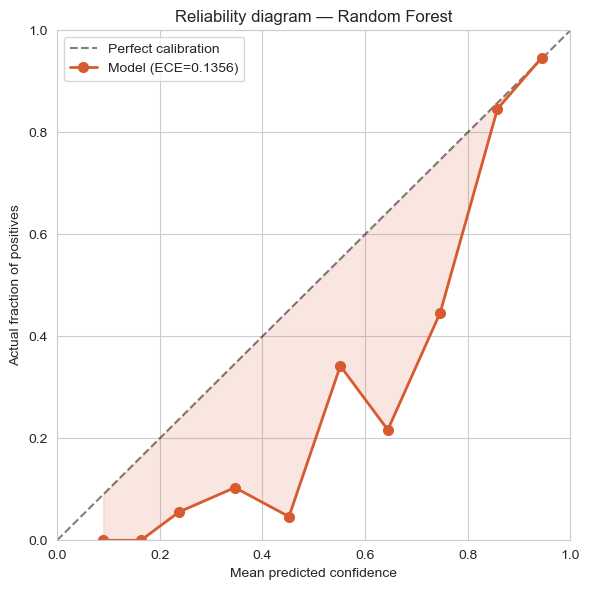

Saved → outputs/models/rf_advanced.pkl


In [38]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training Random Forest on full dataset...")
print(f"Training samples : {X_train_pca.shape[0]}")
print(f"Feature dims     : {X_train_pca.shape[1]}")
print(f"n_estimators     : 200")
print(f"class_weight     : balanced")
print()

rf_clf.fit(X_train_pca, y_train)
print("Training complete.")

y_pred_rf  = rf_clf.predict(X_test_pca)
y_proba_rf = rf_clf.predict_proba(X_test_pca)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
ece_rf = compute_ece(y_test, y_proba_rf)

print()
print("=" * 50)
print("Random Forest Results")
print("=" * 50)
print(f"Accuracy : {acc_rf:.4f}")
print(f"AUC-ROC  : {auc_rf:.4f}")
print(f"ECE      : {ece_rf:.4f}")
print()
print(classification_report(
    y_test, y_pred_rf,
    target_names=['NORMAL', 'PNEUMONIA']
))

plot_reliability_diagram(
    y_test, y_proba_rf,
    model_name='Random Forest',
    save_path=f'{OUTPUT_PLOTS}/reliability_rf.png'
)

joblib.dump(rf_clf, f'{OUTPUT_MODELS}/rf_advanced.pkl')
print("Saved → outputs/models/rf_advanced.pkl")



## Calibration — Isotonic Regression

Isotonic regression is a non-parametric calibration method.
Single assumption: higher raw score → higher probability (monotonicity).
No sigmoid shape assumed — more flexible than Platt scaling from NB01.

Comparison:
  Platt (Notebook 01) — parametric sigmoid, works with less data
  Isotonic (this)     — non-parametric staircase, more flexible

With 5216 training samples and 5-fold CV we have sufficient data
for isotonic regression to be reliable.

The ECE comparison between Platt (NB01) and Isotonic (NB02)
is the core calibration deliverable of Phase 1.

Random Forest ECE before calibration : 0.1356

Fitting Isotonic calibration on Random Forest...

Isotonic calibration result
ECE before isotonic : 0.1356
ECE after  isotonic : 0.1657
Improvement         : -0.0302
AUC after           : 0.9037
Accuracy after      : 0.7708
Verdict             : Still miscalibrated — further tuning needed
Saved → ../outputs/plots/reliability_rf_isotonic.png


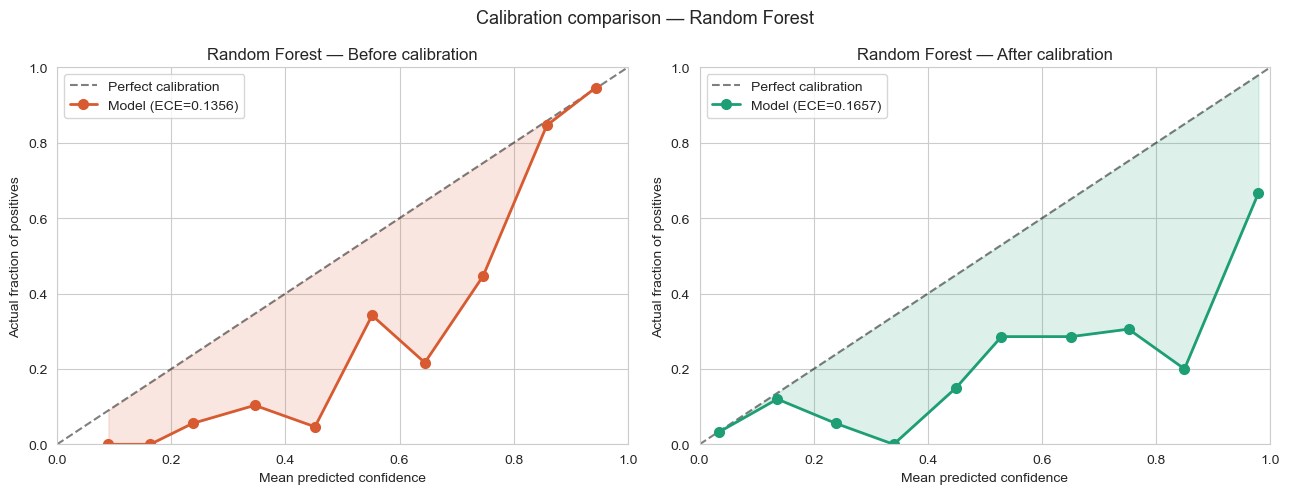

Saved → outputs/models/rf_isotonic.pkl


In [39]:
print(f"Random Forest ECE before calibration : {ece_rf:.4f}")
print()

cal_iso = CalibratedClassifierCV(
    rf_clf,
    method='isotonic',
    cv=5
)

print("Fitting Isotonic calibration on Random Forest...")
cal_iso.fit(X_train_pca, y_train)

y_proba_iso = cal_iso.predict_proba(X_test_pca)[:, 1]
y_pred_iso  = cal_iso.predict(X_test_pca)

ece_after = compute_ece(y_test, y_proba_iso)
auc_after = roc_auc_score(y_test, y_proba_iso)
acc_after = accuracy_score(y_test, y_pred_iso)

print()
print("=" * 50)
print("Isotonic calibration result")
print("=" * 50)
print(f"ECE before isotonic : {ece_rf:.4f}")
print(f"ECE after  isotonic : {ece_after:.4f}")
print(f"Improvement         : {ece_rf - ece_after:.4f}")
print(f"AUC after           : {auc_after:.4f}")
print(f"Accuracy after      : {acc_after:.4f}")

if ece_after < 0.05:
    verdict = "Clinically acceptable — ECE below 0.05"
elif ece_after < 0.10:
    verdict = "Moderate — ECE below 0.10"
else:
    verdict = "Still miscalibrated — further tuning needed"
print(f"Verdict             : {verdict}")

plot_reliability_comparison(
    y_test,
    y_proba_rf,
    y_proba_iso,
    model_name='Random Forest',
    save_path=f'{OUTPUT_PLOTS}/reliability_rf_isotonic.png'
)

joblib.dump(cal_iso, f'{OUTPUT_MODELS}/rf_isotonic.pkl')
print("Saved → outputs/models/rf_isotonic.pkl")



## OOD Detection — Mahalanobis Distance

Clinical motivation: the model must flag inputs it has never seen.
Scans from unfamiliar scanners, rare pathologies, or corrupted
images must not be auto-classified — they should be escalated
to a radiologist.

Mahalanobis distance measures how far a test sample sits from
the training distribution in PCA feature space, accounting for
the full covariance structure of the data.

Steps:
1. Fit detector on training PCA features
2. Compute training scores — defines the normal range
3. Set threshold at 95th percentile of training scores
4. Score all test samples — flag above threshold as OOD
5. Simulate OOD with Gaussian noise — evaluate the detector

In [42]:
print("Fitting Mahalanobis OOD detector on training data...")
print(f"Training samples : {X_train_pca.shape[0]}")
print(f"Feature dims     : {X_train_pca.shape[1]}")
print()

detector = fit_mahalanobis(X_train_pca, y_train)

print("\nComputing OOD scores on training set...")
train_scores = mahalanobis_scores(X_train_pca, detector)
print(f"Train scores — min: {train_scores.min():.2f}, "
      f"max: {train_scores.max():.2f}, "
      f"mean: {train_scores.mean():.2f}")

threshold = set_ood_threshold(
    train_scores,
    percentile=OOD_THRESHOLD_PERCENTILE
)

print("\nComputing OOD scores on test set...")
test_scores    = mahalanobis_scores(X_test_pca, detector)
test_ood_flags = flag_ood(test_scores, threshold)

print()
print("=" * 50)
print("Test set OOD summary")
print("=" * 50)
print(f"Total test samples : {len(test_scores)}")
print(f"Flagged as OOD     : {test_ood_flags.sum()}")
print(f"Flagged percentage : {test_ood_flags.mean()*100:.1f}%")
print(f"Expected ~5% at {OOD_THRESHOLD_PERCENTILE}th percentile")

Fitting Mahalanobis OOD detector on training data...
Training samples : 5216
Feature dims     : 50

Mahalanobis detector fitted.
  Classes         : [np.int64(0), np.int64(1)]
  Feature dims    : 50
  Covariance shape: (50, 50)

Computing OOD scores on training set...
Train scores — min: 4.03, max: 14.54, mean: 6.89
OOD threshold set at 95th percentile: 9.2996

Computing OOD scores on test set...

Test set OOD summary
Total test samples : 624
Flagged as OOD     : 10
Flagged percentage : 1.6%
Expected ~5% at 95th percentile


Simulating OOD inputs — Gaussian noise std=2.0...

OOD detection evaluation
Simulated OOD detection rate : 11.5%
Clean test false alarm rate  : 1.6%
Target: detection >70%,  false alarm <10%
Detection rate low — consider increasing NOISE_STD (currently 2.0)


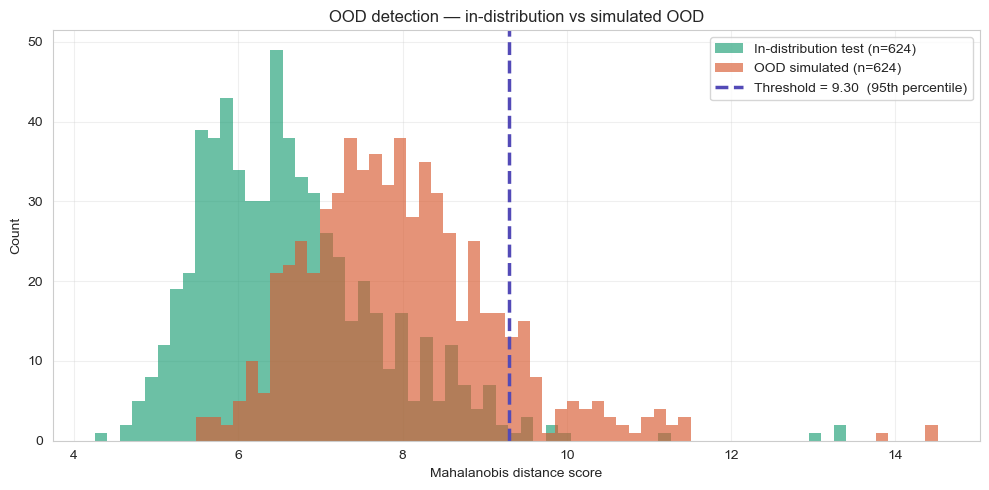

Saved → outputs/plots/ood_score_distribution.png
OOD detector saved → outputs/models/ood_detector.pkl


In [43]:
print(f"Simulating OOD inputs — Gaussian noise std={NOISE_STD}...")
rng            = np.random.default_rng(seed=RANDOM_STATE)
X_ood_sim      = X_test_pca + rng.normal(
                     0, NOISE_STD, X_test_pca.shape)
ood_sim_scores = mahalanobis_scores(X_ood_sim, detector)
ood_sim_flags  = flag_ood(ood_sim_scores, threshold)

detection_rate = ood_sim_flags.mean() * 100
false_alarm    = test_ood_flags.mean() * 100

print()
print("=" * 50)
print("OOD detection evaluation")
print("=" * 50)
print(f"Simulated OOD detection rate : {detection_rate:.1f}%")
print(f"Clean test false alarm rate  : {false_alarm:.1f}%")
print(f"Target: detection >70%,  false alarm <10%")

if detection_rate >= 70 and false_alarm <= 10:
    print("Target met.")
elif detection_rate >= 70:
    print("Detection rate met — false alarm slightly high.")
else:
    print(f"Detection rate low — consider increasing NOISE_STD "
          f"(currently {NOISE_STD})")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(test_scores,
        bins=60, alpha=0.65, color='#1D9E75',
        label=f'In-distribution test (n={len(test_scores)})',
        edgecolor='none')
ax.hist(ood_sim_scores,
        bins=60, alpha=0.65, color='#D85A30',
        label=f'OOD simulated (n={len(ood_sim_scores)})',
        edgecolor='none')
ax.axvline(threshold,
           color='#534AB7', linewidth=2.5, linestyle='--',
           label=f'Threshold = {threshold:.2f}  '
                 f'({OOD_THRESHOLD_PERCENTILE}th percentile)')
ax.set_xlabel('Mahalanobis distance score')
ax.set_ylabel('Count')
ax.set_title('OOD detection — in-distribution vs simulated OOD')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PLOTS}/ood_score_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/plots/ood_score_distribution.png")

joblib.dump(
    {'detector':  detector,
     'threshold': threshold,
     'scaler':    scaler,
     'pca':       pca},
    f'{OUTPUT_MODELS}/ood_detector.pkl'
)
print("OOD detector saved → outputs/models/ood_detector.pkl")

In [45]:
print("=" * 65)
print(f"{'Model':<35} {'Accuracy':>9} {'AUC':>7} {'ECE':>8}")
print("=" * 65)
print(f"{'Random Forest (raw)':<35} "
      f"{acc_rf:>9.4f} {auc_rf:>7.4f} {ece_rf:>8.4f}")
print(f"{'Random Forest + Isotonic':<35} "
      f"{acc_after:>9.4f} {auc_after:>7.4f} {ece_after:>8.4f} *")
print("=" * 65)
print("* = after Isotonic calibration")
print()
print("Primary metric : AUC-ROC")
print("Calibration    : ECE (lower = more trustworthy)")
print()
print("OOD Detection:")
print(f"  Threshold              : {threshold:.4f}")
print(f"  Clean test flagged     : {false_alarm:.1f}%")
print(f"  Simulated OOD detected : {detection_rate:.1f}%")


Model                                Accuracy     AUC      ECE
Random Forest (raw)                    0.7676  0.9153   0.1356
Random Forest + Isotonic               0.7708  0.9037   0.1657 *
* = after Isotonic calibration

Primary metric : AUC-ROC
Calibration    : ECE (lower = more trustworthy)

OOD Detection:
  Threshold              : 9.2996
  Clean test flagged     : 1.6%
  Simulated OOD detected : 11.5%
